# PART 9

Haikal Ali_1103223071_TK46GAB

# SLC 9 — Text Processing and Multiclass Classification

Materi ini membahas pemrosesan teks menggunakan scikit-learn, termasuk text vectorization, feature extraction, text classification, multiclass classification, dan evaluasi model teks.

## Technical Requirements

Disarankan menggunakan environment Python yang terpisah agar pekerjaan aman dari instalasi/library Python lain.

Kebutuhan teknis:
- Git >= 2.46.x
- Python >= 3.9.x
- Repository GitHub sudah di-clone dan environment Python dibuat dari file `requirements.txt`

## 1. Introduction to Text Processing

Text processing adalah tahap penting ketika data yang digunakan berbentuk bahasa natural. Data teks sering berisi noise, format yang tidak seragam, dan informasi yang tidak relevan. Karena komputer tidak memahami teks secara langsung, teks perlu diubah menjadi representasi numerik agar dapat digunakan oleh algoritma machine learning.

Pada bagian ini digunakan corpus `movie_reviews` dari NLTK yang berisi review film dengan label positif dan negatif.

### Getting Ready

Langkah awal adalah memuat library, mengunduh corpus jika belum tersedia, mengambil dokumen dan label, mengubah label menjadi numerik, lalu membagi data menjadi train dan test.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
import nltk
from nltk.corpus import movie_reviews

In [2]:
try:
  movie_reviews.sents()
except LookupError:
  nltk.download('movie_reviews')

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


In [3]:
documents = []
labels = []

for category in movie_reviews.categories():
  for fileid in movie_reviews.fileids(category):
    documents.append(movie_reviews.raw(fileid))
    labels.append(category)

In [4]:
label_map = {
  label: i for i, label in enumerate(sorted(list(set(labels))))
}

numerical_labels = [
  label_map[label] for label in labels
]

label_map

{'neg': 0, 'pos': 1}

In [5]:
subset_size = 500

if len(documents) > subset_size:
  texts_subset, _, labels_subset, _ = train_test_split(
    documents, numerical_labels,
    train_size=subset_size,
    stratify=numerical_labels,
    random_state=2024
  )
else:
  texts_subset = documents
  labels_subset = numerical_labels

X_train, X_test, y_train, y_test = train_test_split(
  texts_subset, labels_subset,
  test_size=0.3, random_state=2024,
  stratify=labels_subset
)

### How to Do It

Raw text diubah menjadi representasi numerik menggunakan `CountVectorizer()`. Stopwords seperti `the`, `a`, dan `an` dihapus karena kata-kata tersebut biasanya memiliki nilai kecil untuk tugas klasifikasi teks.

In [6]:
vectorizer = CountVectorizer(stop_words='english')
X_train_vect = vectorizer.fit_transform(X_train)

In [7]:
X_test_vect = vectorizer.transform(X_test)

### How It Works

`CountVectorizer()` mengubah teks menjadi sparse matrix berisi jumlah kemunculan token. Setiap baris merepresentasikan dokumen, sedangkan setiap kolom merepresentasikan token unik.

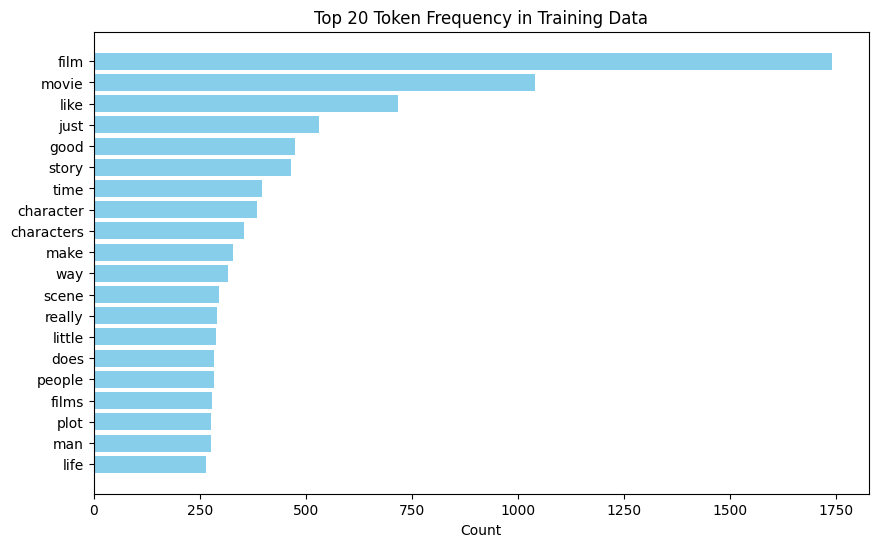

In [8]:
feature_names = vectorizer.get_feature_names_out()
counts = X_train_vect.toarray().sum(axis=0)

N = 20
top_indices = np.argsort(counts)[-N:]

plt.figure(figsize=(10, 6))
plt.barh(feature_names[top_indices], counts[top_indices], color='skyblue')
plt.xlabel('Count')
plt.title('Top 20 Token Frequency in Training Data')
plt.show()

### There's More

Teknik text processing lain mencakup TF-IDF transformation, stemming, lemmatization, stopword removal, dan n-grams. Teknik ini dapat memperkuat pipeline preprocessing teks dan meningkatkan performa model.

### Hands-on Exercises

Alur latihan:
1. Clone repository GitHub dan install library yang diperlukan.
2. Pilih dataset teks atau buat dataset sendiri.
3. Bersihkan dan proses teks dengan menangani punctuation, case normalization, dan tokenization.
4. Gunakan `CountVectorizer()` atau `TfidfVectorizer()` untuk mengubah teks menjadi data numerik.
5. Bagi dataset menjadi training dan testing.
6. Latih model machine learning menggunakan data yang sudah diproses.
7. Evaluasi model menggunakan metrik seperti accuracy atau F1-score.
8. Visualisasikan token frequency atau aspek lain dari data teks yang sudah diproses.

## 2. Text Vectorization Techniques

Text vectorization mengubah teks mentah menjadi representasi numerik agar dapat diproses oleh algoritma machine learning. Teknik yang dibahas adalah Bag of Words, TF-IDF, dan word embeddings secara konseptual.

Bag of Words merepresentasikan teks berdasarkan frekuensi kata. TF-IDF memberi bobot lebih besar pada kata yang khas dalam dokumen tertentu dan jarang muncul di dokumen lain. Word embeddings merepresentasikan kata sebagai vektor dense yang menangkap hubungan semantik.

### Getting Ready

Bagian ini menggunakan corpus `reuters` dari NLTK. Label dibuat menggunakan kategori pertama dari setiap dokumen untuk menyederhanakan klasifikasi.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
import nltk
from nltk.corpus import reuters

In [10]:
try:
  reuters.fileids()
except LookupError:
  nltk.download('reuters')

[nltk_data] Downloading package reuters to /root/nltk_data...


In [11]:
documents = reuters.fileids()

texts = [reuters.raw(doc_id) for doc_id in documents]
labels = [reuters.categories(doc_id)[0] for doc_id in documents]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
  texts, labels, test_size=0.5, random_state=2024
)

### How to Do It

Dua teknik vectorization yang digunakan adalah Bag of Words dengan `CountVectorizer()` dan TF-IDF dengan `TfidfVectorizer()`.

In [13]:
bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

In [14]:
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

### How It Works

Bag of Words menghitung frekuensi kata tanpa memperhatikan urutan dan struktur gramatikal. TF-IDF menyesuaikan frekuensi kata berdasarkan kelangkaannya di seluruh dokumen, sehingga kata yang lebih khas mendapat bobot lebih tinggi.

In [15]:
vis_tfidf_vectorizer = TfidfVectorizer(stop_words='english')
vis_X_train_tfidf = vis_tfidf_vectorizer.fit_transform(X_train)

In [16]:
feature_names = vis_tfidf_vectorizer.get_feature_names_out()
tfidf_means = vis_X_train_tfidf.toarray().mean(axis=0)

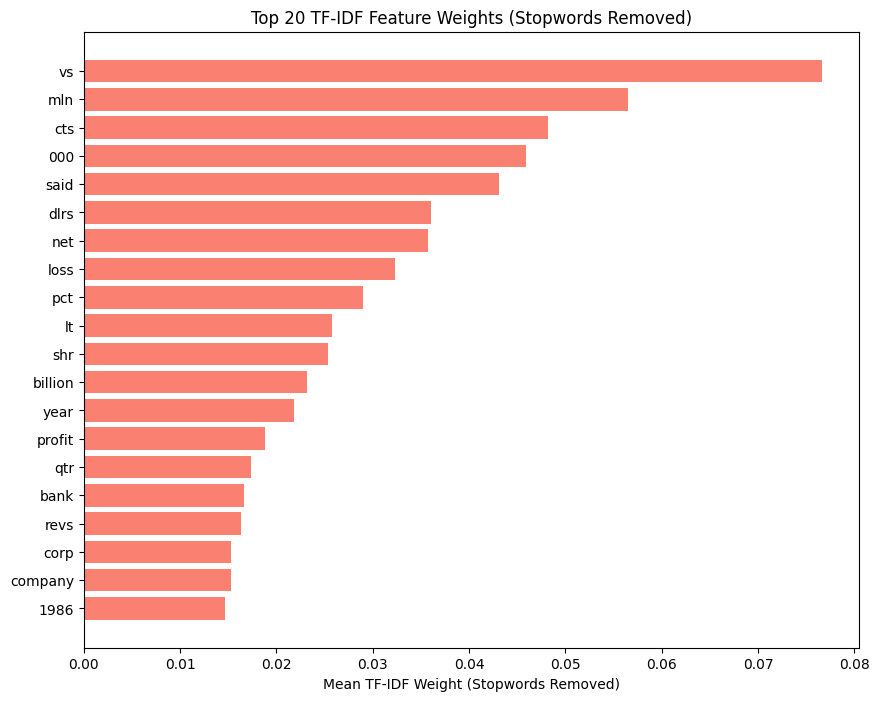

In [17]:
N = 20

if len(feature_names) < N:
  N = len(feature_names)

if N > 0:
  sorted_indices_ascending = np.argsort(tfidf_means)
  top_n_plotting_indices = sorted_indices_ascending[-N:]

  plot_feature_names = feature_names[top_n_plotting_indices]
  plot_tfidf_means = tfidf_means[top_n_plotting_indices]

  plt.figure(figsize=(10, 8))
  plt.barh(plot_feature_names, plot_tfidf_means, color='salmon')
  plt.xlabel('Mean TF-IDF Weight (Stopwords Removed)')
  plt.title(f'Top {N} TF-IDF Feature Weights (Stopwords Removed)')
else:
  plt.figure(figsize=(10, 6))
  plt.barh([], [])
  plt.xlabel('Mean TF-IDF Weight (Stopwords Removed)')
  plt.title('TF-IDF Feature Weights (No non-stopword features to display)')

plt.show()

### There's More

Word embeddings seperti Word2Vec dan GloVe merepresentasikan kata sebagai dense vector yang menangkap hubungan semantik. scikit-learn tidak menyediakan implementasi langsung untuk membuat embeddings, tetapi embeddings dari luar dapat diintegrasikan ke model machine learning.

### Hands-on Exercises

Alur latihan:
1. Clone repository GitHub dan pastikan library sudah terpasang.
2. Pilih dataset teks untuk vectorization.
3. Bersihkan dan proses dataset dengan menangani punctuation, case normalization, dan tokenization.
4. Gunakan `CountVectorizer()` dan `TfidfVectorizer()`.
5. Bagi dataset menjadi training dan testing.
6. Latih dan evaluasi model menggunakan fitur hasil vectorization.
7. Opsional: coba integrasi pretrained word embeddings.
8. Visualisasikan dan analisis feature weights dari TF-IDF.

## 3. Feature Extraction from Text

Feature extraction dari teks bertujuan mengambil pola atau atribut bermakna dari data teks. Teknik yang dibahas mencakup n-grams, part-of-speech tagging, dan named entity recognition.

### Getting Ready

Bagian ini menggunakan corpus `brown` dari NLTK. Corpus ini berisi 500 sumber yang dikategorikan berdasarkan genre.

In [18]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
import nltk
from nltk.corpus import brown
from nltk.util import ngrams as nltk_ngrams
import matplotlib.pyplot as plt
from collections import Counter
from nltk.corpus import stopwords

In [19]:
nltk.download('brown', quiet=True)
nltk.download('punkt', quiet=True)

True

In [20]:
texts = []
labels = []

In [21]:
categories_to_use = brown.categories()[:2]
num_sents_per_category = 2

for i, category in enumerate(categories_to_use):
  category_sents = brown.sents(categories=category)

  for sent_tokens in category_sents[:num_sents_per_category]:
    texts.append(" ".join(sent_tokens))
    labels.append(i)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
  texts, labels, test_size=0.5, random_state=2024
)

### How to Do It

N-grams digunakan untuk menangkap urutan kata. POS tagging digunakan untuk memberi label kelas gramatikal pada token.

In [23]:
ngram_vectorizer = CountVectorizer(ngram_range=(1, 2))
X_train_ngram = ngram_vectorizer.fit_transform(X_train)
X_test_ngram = ngram_vectorizer.transform(X_test)

In [24]:
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

True

In [25]:
print("--- POS Tagging of Tokens and N-grams in Training Sentences ---")

for i, text in enumerate(X_train):
  print(f"\nOriginal Sentence {i+1}: \"{text}\"")

  tokens = nltk.word_tokenize(text)
  pos_tags = nltk.pos_tag(tokens)

  print("  Tagged Tokens (Unigrams):")

  if pos_tags:
    unigram_str = " ".join([
      f"{token}/{tag}"
      for token, tag in pos_tags
    ])
    print(f"    {unigram_str}")
  else:
    print("    (No tokens to tag)")

  if len(pos_tags) >= 2:
    print("  Tagged Bigrams:")
    tagged_bigrams = list(nltk_ngrams(pos_tags, 2))

    for bigram_tuple in tagged_bigrams:
      item1, item2 = bigram_tuple
      bigram_display_str = (
        f"{item1[0]}/{item1[1]} "
        f"{item2[0]}/{item2[1]}"
      )
      print(f"    {bigram_display_str}")
  else:
    print("(Not enough tagged tokens for bigrams)")

print("\n--- End of POS Tagging Display ---")

--- POS Tagging of Tokens and N-grams in Training Sentences ---

Original Sentence 1: "Northern liberals are the chief supporters of civil rights and of integration ."
  Tagged Tokens (Unigrams):
    Northern/NNP liberals/NNS are/VBP the/DT chief/JJ supporters/NNS of/IN civil/JJ rights/NNS and/CC of/IN integration/NN ./.
  Tagged Bigrams:
    Northern/NNP liberals/NNS
    liberals/NNS are/VBP
    are/VBP the/DT
    the/DT chief/JJ
    chief/JJ supporters/NNS
    supporters/NNS of/IN
    of/IN civil/JJ
    civil/JJ rights/NNS
    rights/NNS and/CC
    and/CC of/IN
    of/IN integration/NN
    integration/NN ./.

Original Sentence 2: "Dan Morgan told himself he would forget Ann Turner ."
  Tagged Tokens (Unigrams):
    Dan/NNP Morgan/NNP told/VBD himself/PRP he/PRP would/MD forget/VB Ann/NNP Turner/NNP ./.
  Tagged Bigrams:
    Dan/NNP Morgan/NNP
    Morgan/NNP told/VBD
    told/VBD himself/PRP
    himself/PRP he/PRP
    he/PRP would/MD
    would/MD forget/VB
    forget/VB Ann/NNP
    An

Label POS yang muncul di contoh:
- NN: noun singular atau mass
- NNS: noun plural
- JJ: adjective
- VB: verb base form
- RB: adverb
- PRP: pronoun
- CC: coordinating conjunction
- DT: determiner
- IN: preposition atau subordinating conjunction
- CD: cardinal number
- FW: foreign word
- NNP: proper noun singular
- NNPS: proper noun plural
- VBZ: verb third-person singular present
- VBD: verb past tense
- VBG: verb gerund atau present participle
- VBN: verb past participle
- VBP: verb non-third-person singular present

### How It Works

N-grams menangkap urutan kata sehingga konteks yang tidak terlihat dari kata tunggal dapat muncul. POS tagging mengelompokkan kata berdasarkan tipe gramatikal. NER mengidentifikasi entitas bernama seperti orang, organisasi, dan lokasi.

In [26]:
nltk.download('stopwords', quiet=True)

True

In [27]:
stop_words_set = set(stopwords.words('english'))
all_individual_pos_tags = []

for text_content in X_train:
  tokens = nltk.word_tokenize(text_content)

  filtered_tokens = [
    token for token in tokens
    if token.lower() not in stop_words_set
  ]

  if not filtered_tokens:
    continue

  pos_tagged_tokens = nltk.pos_tag(filtered_tokens)

  for _, tag in pos_tagged_tokens:
    all_individual_pos_tags.append(tag)

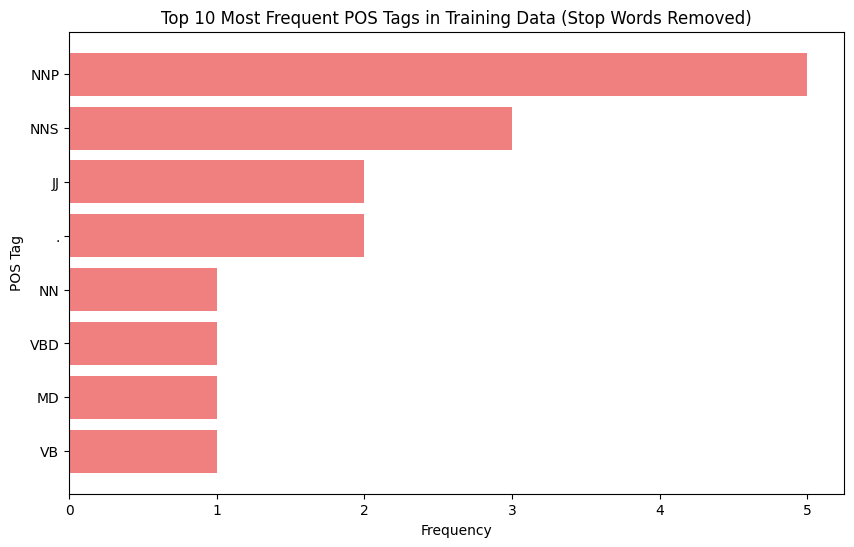

In [28]:
pos_tag_counter = Counter(all_individual_pos_tags)
top_10_pos_tags = pos_tag_counter.most_common(10)

if top_10_pos_tags:
  tags, counts = zip(*top_10_pos_tags)

  plt.figure(figsize=(10, 6))
  plt.barh(list(tags), list(counts), color='lightcoral')
  plt.xlabel('Frequency')
  plt.ylabel('POS Tag')
  plt.title('Top 10 Most Frequent POS Tags in Training Data (Stop Words Removed)')
  plt.gca().invert_yaxis()
  plt.show()
else:
  print(
    "No POS tags found to display. "
    "Check X_train data and stop word filtering process."
  )

### There's More

Teknik feature extraction lanjutan mencakup dependency parsing dan sentiment analysis. Teknik tersebut dapat memperkaya data teks dan membantu predictive modeling.

### Hands-on Exercises

Alur latihan:
1. Clone repository GitHub dan pastikan semua library termasuk spaCy sudah terpasang.
2. Pilih dataset teks yang sesuai untuk feature extraction.
3. Preprocess dan bersihkan dataset.
4. Ekstrak n-grams menggunakan `CountVectorizer()` dengan berbagai `ngram_range`.
5. Terapkan POS tagging dan NER menggunakan spaCy.
6. Latih model text classification menggunakan fitur yang diekstrak.
7. Evaluasi model dengan accuracy, precision, recall, dan F1-score.
8. Visualisasikan hasil feature extraction seperti n-gram frequencies atau named entity distributions.

## 4. Implementing Text Classification Models

Text classification digunakan untuk mengelompokkan data teks, misalnya sentiment analysis atau topic classification. Pada bagian ini digunakan Naive Bayes, SVM, dan logistic regression.

### Getting Ready

Bagian ini kembali menggunakan corpus `brown`.

In [29]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import nltk
from nltk.corpus import brown
import matplotlib.pyplot as plt

In [30]:
try:
  nltk.data.find('corpora/brown.zip')
except LookupError:
  nltk.download('brown', quiet=True)

try:
  nltk.data.find('tokenizers/punkt')
except LookupError:
  nltk.download('punkt', quiet=True)

In [31]:
document_ids = brown.fileids()

texts = [
  ' '.join(brown.words(file_id))
  for file_id in document_ids
]

raw_labels = [
  brown.categories(file_id)[0]
  for file_id in document_ids
]

In [32]:
unique_raw_labels = sorted(list(set(raw_labels)))

label_to_int_mapping = {
  label: i
  for i, label in enumerate(unique_raw_labels)
}

labels = [
  label_to_int_mapping[label]
  for label in raw_labels
]

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
  texts, labels, test_size=0.5,
  stratify=labels, random_state=2024
)

### How to Do It

Teks diubah dengan TF-IDF, lalu tiga model dilatih dan dievaluasi.

In [34]:
vectorizer = TfidfVectorizer()
X_train_vect = vectorizer.fit_transform(X_train)
X_test_vect = vectorizer.transform(X_test)

In [35]:
nb_clf = MultinomialNB()
nb_clf.fit(X_train_vect, y_train)

MultinomialNB()

In [36]:
svm_clf = SVC(random_state=2024)
svm_clf.fit(X_train_vect, y_train)

SVC(random_state=2024)

In [37]:
lr_clf = LogisticRegression(random_state=2024, max_iter=1000)
lr_clf.fit(X_train_vect, y_train)

LogisticRegression(max_iter=1000, random_state=2024)

In [38]:
models = {
  'Naive Bayes': nb_clf,
  'SVM': svm_clf,
  'Logistic Regression': lr_clf
}

for name, model in models.items():
  y_pred = model.predict(X_test_vect)
  print(f'{name} Classification Report:')

  report_dict = classification_report(
    y_test, y_pred,
    target_names=unique_raw_labels,
    output_dict=True,
    zero_division=0
  )

  report_df = pd.DataFrame(report_dict).transpose()

  styled_df = (
    report_df
    .style
    .background_gradient(
      cmap='Blues',
      subset=['precision', 'recall', 'f1-score']
    )
    .format({
      'precision': '{:.3f}',
      'recall': '{:.3f}',
      'f1-score': '{:.3f}',
      'support': '{:.0f}'
    })
  )

  display(styled_df)
  print("\n")

Naive Bayes Classification Report:


,precision,recall,f1-score,support
adventure,0.000,0.000,0.000,15
belles_lettres,0.173,1.000,0.295,37
editorial,0.000,0.000,0.000,14
fiction,0.000,0.000,0.000,14
government,0.000,0.000,0.000,15
hobbies,0.000,0.000,0.000,18
humor,0.000,0.000,0.000,4
learned,0.556,0.500,0.526,40
lore,0.000,0.000,0.000,24
mystery,0.000,0.000,0.000,12




SVM Classification Report:


,precision,recall,f1-score,support
adventure,0.400,0.133,0.200,15
belles_lettres,0.236,0.946,0.378,37
editorial,0.000,0.000,0.000,14
fiction,0.312,0.357,0.333,14
government,0.000,0.000,0.000,15
hobbies,0.000,0.000,0.000,18
humor,0.000,0.000,0.000,4
learned,0.424,0.700,0.528,40
lore,0.000,0.000,0.000,24
mystery,0.000,0.000,0.000,12




Logistic Regression Classification Report:


,precision,recall,f1-score,support
adventure,1.000,0.067,0.125,15
belles_lettres,0.231,0.919,0.370,37
editorial,0.000,0.000,0.000,14
fiction,0.000,0.000,0.000,14
government,0.000,0.000,0.000,15
hobbies,1.000,0.056,0.105,18
humor,0.000,0.000,0.000,4
learned,0.377,0.725,0.496,40
lore,0.000,0.000,0.000,24
mystery,0.000,0.000,0.000,12


### How It Works

Naive Bayes cocok untuk data teks karena sifat probabilistiknya dan efisiensinya pada ruang fitur yang besar. SVM dapat menangkap hubungan kompleks dengan hyperplane. Logistic regression memberi prediksi yang kuat dan probabilitas yang mudah diinterpretasikan.

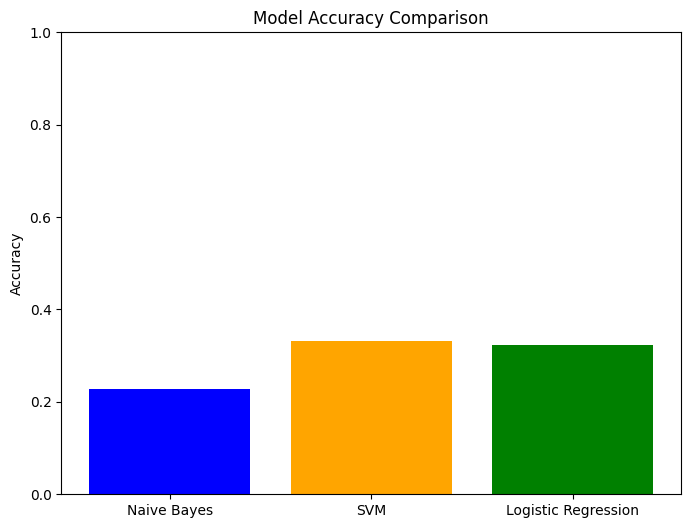

In [39]:
model_accuracies = {}

for model_name, model_instance in models.items():
  y_pred = model_instance.predict(X_test_vect)

  report_dict = classification_report(
    y_test, y_pred,
    target_names=unique_raw_labels,
    output_dict=True,
    zero_division=0
  )

  model_accuracies[model_name] = report_dict['accuracy']

plt.figure(figsize=(8, 6))
plt.bar(
  model_accuracies.keys(),
  model_accuracies.values(),
  color=['blue', 'orange', 'green']
)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)
plt.show()

### There's More

Teknik tambahan seperti ensemble models, deep learning-based methods, hyperparameter tuning, dan feature extraction berbasis embeddings dapat meningkatkan performa text classification.

### Hands-on Exercises

Alur latihan:
1. Clone repository GitHub dan install library yang diperlukan.
2. Pilih dataset untuk text classification.
3. Bersihkan dan preprocess dataset.
4. Vectorize teks menggunakan TF-IDF atau metode vectorization lain.
5. Latih beberapa model klasifikasi seperti Naive Bayes, SVM, dan logistic regression.
6. Evaluasi model menggunakan accuracy, precision, recall, dan F1-score.
7. Visualisasikan performa model dan interpretasikan hasil klasifikasi.

## 5. Multiclass Classification Strategies

Multiclass classification digunakan ketika target memiliki lebih dari dua kelas. Strategi yang dibahas adalah one-vs-rest (OvR), one-vs-one (OvO), dan hierarchical classification secara konseptual.

### Getting Ready

Bagian ini menggunakan corpus `brown` dari NLTK.

In [40]:
import nltk
from nltk.corpus import brown
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import pandas as pd

In [41]:
try:
  _ = brown.fileids()
except LookupError:
  nltk.download('brown', quiet=True)
except Exception:
  nltk.download('brown', quiet=True)

In [42]:
file_ids = brown.fileids()
texts = [brown.raw(file_id) for file_id in file_ids]
labels = [brown.categories(file_id)[0] for file_id in file_ids]

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
  texts, labels, test_size=0.5, random_state=2024
)

### How to Do It

Dua strategi yang digunakan adalah OvR dan OvO dengan logistic regression.

In [44]:
vectorizer = TfidfVectorizer()
X_train_vect = vectorizer.fit_transform(X_train)
X_test_vect = vectorizer.transform(X_test)

In [45]:
ovr_clf = OneVsRestClassifier(LogisticRegression(
  random_state=2024, solver='liblinear'
))
ovr_clf.fit(X_train_vect, y_train)
y_pred_ovr = ovr_clf.predict(X_test_vect)

In [46]:
ovo_clf = OneVsOneClassifier(LogisticRegression(
  random_state=2024, solver='liblinear'
))
ovo_clf.fit(X_train_vect, y_train)
y_pred_ovo = ovo_clf.predict(X_test_vect)

In [47]:
print('One-vs-Rest Classification Report:')

report_ovr_dict = classification_report(
  y_test, y_pred_ovr,
  zero_division=0,
  output_dict=True
)

report_ovr_df = pd.DataFrame(report_ovr_dict).transpose()

styled_ovr_df = (
  report_ovr_df
  .style
  .background_gradient(
    cmap='Blues',
    subset=['precision', 'recall', 'f1-score']
  )
  .format({
    'precision': '{:.3f}',
    'recall': '{:.3f}',
    'f1-score': '{:.3f}',
    'support': '{:.0f}'
  })
)

display(styled_ovr_df)
print("\n")

One-vs-Rest Classification Report:


,precision,recall,f1-score,support
adventure,0.400,0.143,0.211,14
belles_lettres,0.206,0.568,0.302,37
editorial,0.000,0.000,0.000,9
fiction,0.000,0.000,0.000,13
government,0.000,0.000,0.000,19
hobbies,0.000,0.000,0.000,21
humor,0.000,0.000,0.000,6
learned,0.282,0.861,0.425,36
lore,0.000,0.000,0.000,29
mystery,0.000,0.000,0.000,12


In [48]:
print('One-vs-One Classification Report:')

report_ovo_dict = classification_report(
  y_test, y_pred_ovo,
  zero_division=0,
  output_dict=True
)

report_ovo_df = pd.DataFrame(report_ovo_dict).transpose()

styled_ovo_df = (
  report_ovo_df
  .style
  .background_gradient(
    cmap='Blues',
    subset=['precision', 'recall', 'f1-score']
  )
  .format({
    'precision': '{:.3f}',
    'recall': '{:.3f}',
    'f1-score': '{:.3f}',
    'support': '{:.0f}'
  })
)

display(styled_ovo_df)
print("\n")

One-vs-One Classification Report:


,precision,recall,f1-score,support
adventure,0.000,0.000,0.000,14
belles_lettres,0.200,0.703,0.311,37
editorial,0.000,0.000,0.000,9
fiction,0.000,0.000,0.000,13
government,0.000,0.000,0.000,19
hobbies,0.000,0.000,0.000,21
humor,0.000,0.000,0.000,6
learned,0.292,0.861,0.437,36
lore,0.000,0.000,0.000,29
mystery,0.000,0.000,0.000,12


### How It Works

OvR membangun satu classifier untuk setiap kelas dengan membedakan satu kelas dari semua kelas lain. OvO membangun classifier untuk setiap pasangan kelas, sehingga jumlah model lebih banyak, tetapi dapat memberi performa yang lebih baik pada dataset seimbang.

### There's More

Hierarchical classification menyusun tugas klasifikasi ke dalam beberapa level seperti struktur pohon. Pendekatan ini dapat membantu skenario klasifikasi yang kompleks dan meningkatkan akurasi prediksi.

### Hands-on Exercises

Alur latihan:
1. Clone repository GitHub dan install library yang diperlukan.
2. Pilih multiclass text dataset.
3. Preprocess dan bersihkan dataset.
4. Ubah teks menjadi fitur numerik menggunakan TF-IDF.
5. Implementasikan dan bandingkan strategi OvR dan OvO.
6. Evaluasi classifier menggunakan accuracy, precision, recall, dan F1-score.
7. Visualisasikan dan interpretasikan hasil klasifikasi.

## 6. Evaluating Text Models

Evaluasi model teks menggunakan metrik seperti precision, recall, F1-score, dan confusion matrix. Metrik ini membantu melihat seberapa baik model mengklasifikasikan data teks dan di mana model melakukan kesalahan.

### Getting Ready

Bagian ini menggunakan corpus `movie_reviews` dari NLTK dan logistic regression sebagai model contoh.

In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
  precision_score, recall_score, f1_score,
  confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import movie_reviews
import random
import pandas as pd

In [50]:
try:
  movie_reviews.categories()
except LookupError:
  nltk.download('movie_reviews')

In [51]:
documents = []

for category in movie_reviews.categories():
  for fileid in movie_reviews.fileids(category):
    documents.append((
      list(movie_reviews.words(fileid)),
      category
    ))

In [52]:
random.seed(2024)
random.shuffle(documents)

In [53]:
texts = [" ".join(words) for words, category in documents]
labels = [category for words, category in documents]

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
  texts, labels, test_size=0.5, random_state=2024
)

### How to Do It

Teks di-vectorize menggunakan TF-IDF, model logistic regression dilatih, lalu hasilnya dievaluasi.

In [55]:
vectorizer = TfidfVectorizer()
X_train_vect = vectorizer.fit_transform(X_train)
X_test_vect = vectorizer.transform(X_test)

In [56]:
clf = LogisticRegression(random_state=2024)
clf.fit(X_train_vect, y_train)

LogisticRegression(random_state=2024)

In [57]:
y_pred = clf.predict(X_test_vect)

In [58]:
print("Precision:", precision_score(
  y_test, y_pred, average='weighted', zero_division=0
))
print("Recall:", recall_score(
  y_test, y_pred, average='weighted', zero_division=0
))
print("F1 Score:", f1_score(
  y_test, y_pred, average='weighted', zero_division=0
))

Precision: 0.8034174884733607
Recall: 0.803
F1 Score: 0.8029765558512367


In [59]:
report_dict = classification_report(
  y_test, y_pred,
  labels=clf.classes_,
  target_names=clf.classes_,
  output_dict=True,
  zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

print("\nClassification Report:")
display(report_df.style.set_caption("Classification Report"))


Classification Report:


,precision,recall,f1-score,support
neg,0.791016,0.818182,0.804369,495.000000
pos,0.815574,0.788119,0.801611,505.000000
accuracy,0.803000,0.803000,0.803000,0.803000
macro avg,0.803295,0.803150,0.802990,1000.000000
weighted avg,0.803417,0.803000,0.802977,1000.000000


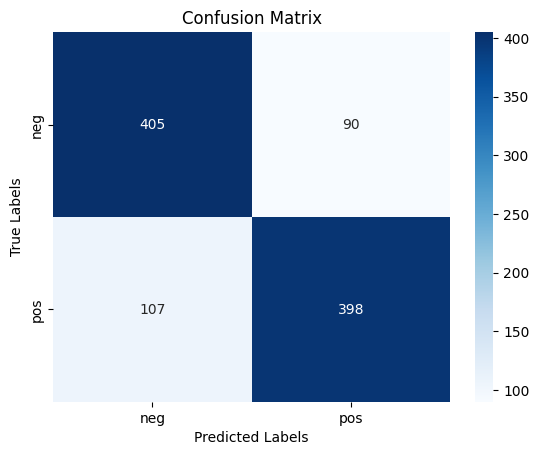

In [60]:
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)

sns.heatmap(
  cm, annot=True, fmt='d',
  xticklabels=clf.classes_,
  yticklabels=clf.classes_,
  cmap='Blues'
)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

### How It Works

Precision mengukur ketepatan prediksi positif. Recall mengukur kemampuan model menemukan instance positif. F1-score menggabungkan precision dan recall. Confusion matrix memperlihatkan prediksi benar dan salah untuk setiap kelas.

### There's More

Metrik lain seperti ROC curve dan AUC dapat memberi insight tambahan, terutama untuk binary classification. Cross-validation juga dapat membantu mendapatkan evaluasi yang lebih robust.

### Hands-on Exercises

Alur latihan:
1. Clone repository GitHub dan install library yang diperlukan.
2. Pilih dataset teks untuk klasifikasi.
3. Preprocess dan bersihkan dataset.
4. Latih model text classification seperti logistic regression.
5. Evaluasi model menggunakan precision, recall, F1-score, dan confusion matrix.
6. Visualisasikan metrik untuk menginterpretasikan performa model.
7. Coba metrik tambahan dan cross-validation untuk evaluasi yang lebih menyeluruh.

## 7. Practical Exercises in Text Processing

Bagian akhir berisi latihan untuk memperkuat pemrosesan teks, vectorization, feature extraction, dan multiclass classification.

### Exercise 1: Preprocessing and Vectorizing Text

Langkah implementasi:
1. Load libraries.
2. Load dataset.
3. Preprocess data dengan basic cleaning.
4. Vectorize text.

### Exercise 2: Feature Extraction with N-grams

Langkah implementasi:
1. Load libraries.
2. Load dataset.
3. Extract n-gram features.

### Exercise 3: Building and Evaluating a Multiclass Classifier

Langkah implementasi:
1. Load libraries.
2. Load dataset.
3. Vectorize text.
4. Split data.
5. Train classifier.
6. Make predictions and evaluate.